<a href="https://colab.research.google.com/github/effiongdebra-spec/effiongdebra-spec/blob/main/DataStructures_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install Scanpy

To begin, the proper software and functions must be downloaded. Scanpy will be used for the analysis and visualization of the PBMCs.

In [ ]:
!pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from __future__ import annotations

import anndata as ad
import pooch

# Upload Dataset

The dataset was obtained from the 10x Genomics website. It is a 5K Human peripheral blood mononuclear cell (PBMC) dataset that was produced from a sample from a healthy male donor (Donor 2) between the age of 18-35. The instrument used was the Chromium X series, and libraries were analyzed using the cellranger multi pipeline.

The link to the dataset can be found here: https://www.10xgenomics.com/datasets/5k_Human_Donor2_PBMC_3p_gem-x

The dataset that was downloaded is titled 'Gene Expression - Feature / cell matrix HDF5 (per-sample)'.

In [ ]:
## Importing from Google Drive
adata = sc.read_10x_h5('/content/drive/MyDrive/Data Structures Project 1/5k_Human_Donor2_PBMC_3p_gem-x_Multiplex_count_raw_feature_bc_matrix.h5')



/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
## Making sure that there are no future duplicates
adata.var_names_make_unique()

#Preprocessing

For the preprocessing step, a scanpy function called calculate_qc_metrix() is used to find the proportion of counts for a specific gene population. For this project, the proportions of mitochondrial genes will be analyzed.

In [ ]:
## Proportions of mitochondrial genes in Donor 2
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], log1p=True, inplace=True)

# Visualization

The proportions of the mitochondrial genes can be visualized based on the metrics obtained during the quality control. In the visualization, we want to see:
- Number of genes per cell
- Number of UMI counts per cell
- Percentage of mitochondrial genes per cell
- Apply filtering thresholds (justify your choices).
- Filter cells with extreme values (e.g., > 5% mitochondrial
content or very low gene counts).

Initially when plotting these proportions, I ran into a visualization problem where the violin plots were heavily skewed. From there, the cells needed to be filtered to get rid of outliers.

In [ ]:
## Filtering cells with standard thresholds
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

I started with standard filtering thresholds to see how it would fit my dataset. Then I visualized it.

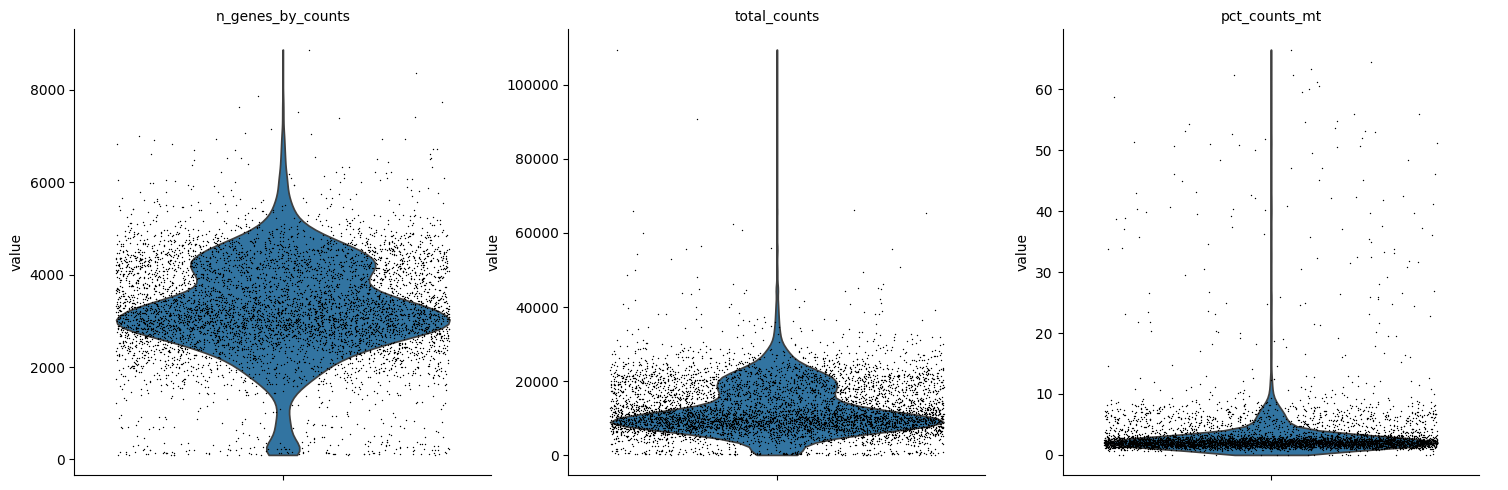

In [ ]:
## Number of genes per cell, number of UMI counts per cell, and percentage of mitochondrial genes per cell
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


The filter thresholds are verified through scatter plots.

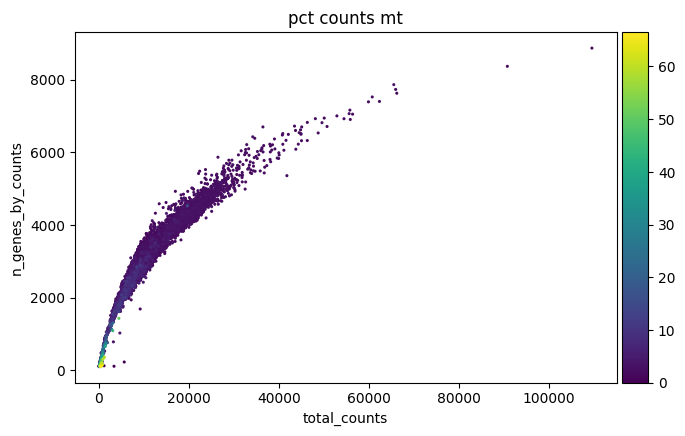

In [ ]:
## Filtered thresholds
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Based on the scatter plot, the dead cells that are marked by green and blue in the bottom left quadrant of the graph as well as the outliers that are in the top right quadrant of the graph need to be removed.


In [ ]:
## Filtering cells with extreme values
adata = adata[
    (adata.obs.n_genes_by_counts < 6000) & (adata.obs.n_genes_by_counts > 500) & (adata.obs.total_counts < 50000) & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
## Saving the count data
adata.layers["counts"] = adata.X.copy()

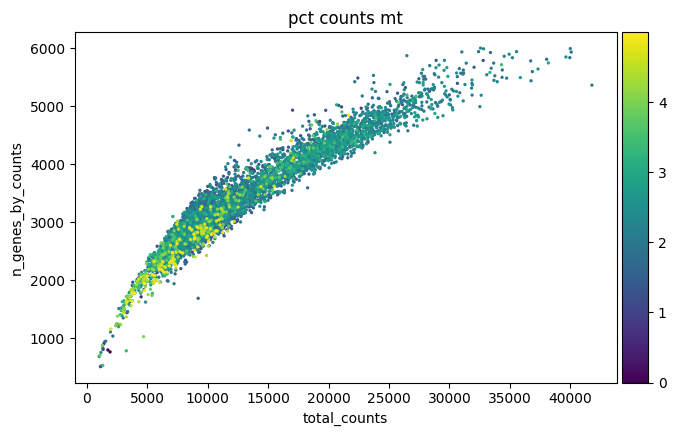

In [ ]:
## Filtered thresholds
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

The quality control allowed for the visualization of the number of genes per cell, the total UMI per cell, and the percentage of mitochondria gene counts per cell. These proportions were then constricted to remove cells that would not be useful for analysis such as dead cells or duplicated cells.

# Normalization and Feature Selection

The dataset is normalized to the median total count to scale each cell count to the same number. From here, we can get relative expression values of the mitochondrial genes.

In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

The dimensionality of the dataset is reduced by selecting features that contain the most informative genes. The highly variable genes are then filtered.

In [ ]:
## Install a package that allows the marking of highly variable genes
!pip install scikit-misc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 4.2 MB/s eta 0:00:00


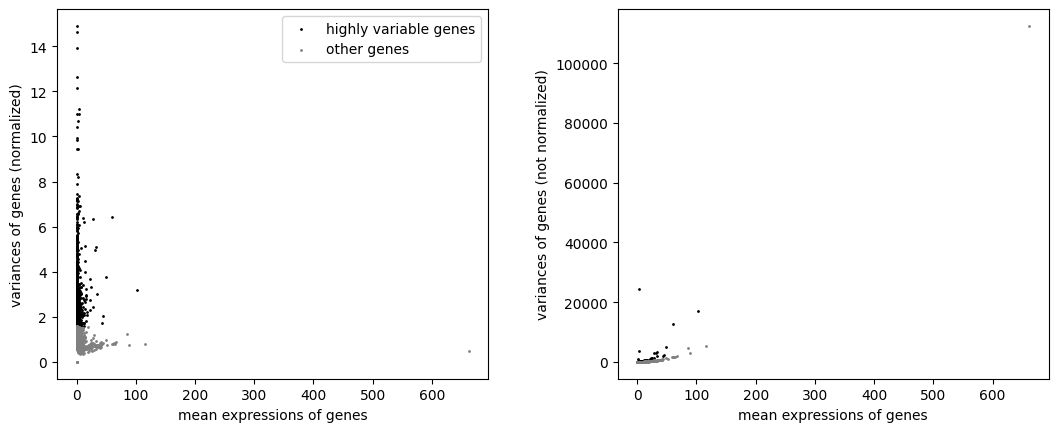

In [ ]:
## Mark highly variable genes
sc.pp.highly_variable_genes(
    adata,
    layer="counts",
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    flavor="seurat_v3",
)
## Filter and plot the highly variable genes
sc.pl.highly_variable_genes(adata)

# Dimensionality Reduction

The dimensionality of the dataset is reduced by applying principle component analysis (PCA) which shows the variation in the dataset and reduces noise.

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


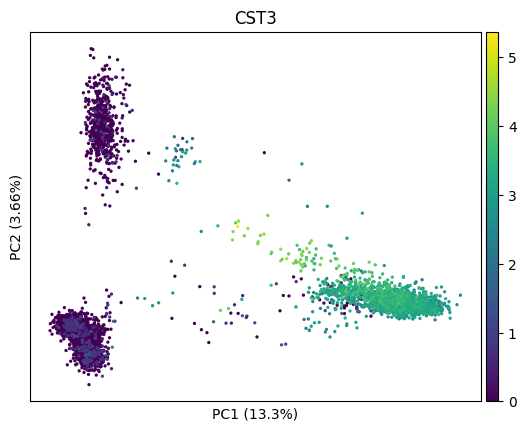

In [ ]:
## Running PCA
adata.layers["scaled"] = adata.X.copy()
sc.pp.scale(adata, layer="scaled")
sc.pp.pca(adata, layer="scaled", svd_solver="arpack")
sc.pp.pca(adata, layer="scaled", svd_solver="arpack")
## Creating a scatterplot for visualization
sc.pl.pca(adata, annotate_var_explained=True, color="CST3")

Each principle component is then viewed and ranked through a rough estimate calculation. This combines the genes into indexes that show patterns of co-expression.

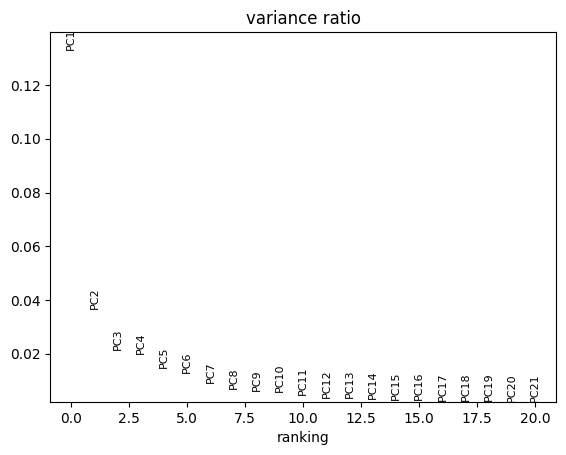

In [ ]:
## Plotting the variance ratio of each principal component
sc.pl.pca_variance_ratio(adata, n_pcs=20)

PC1 and PC2 showed to be the most important variations in my dataset, so the genes that were compressed into those indexes are viewed.

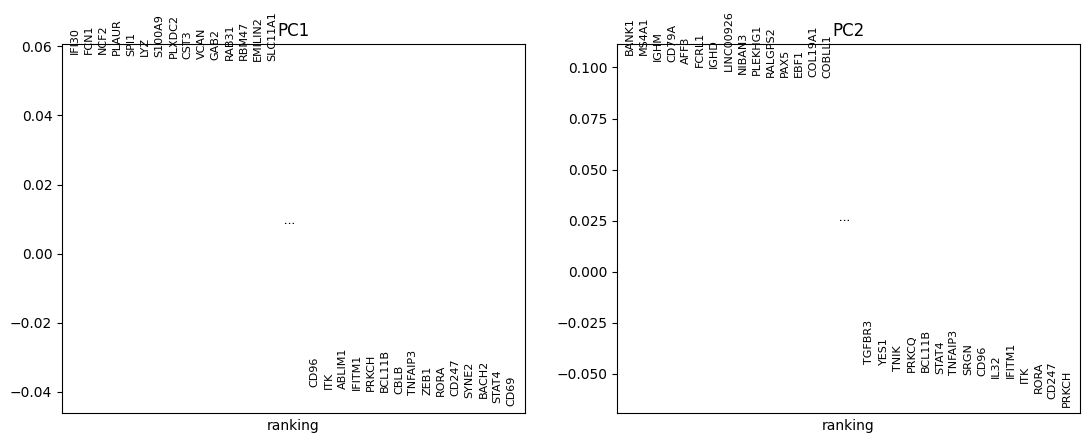

In [ ]:
## Genes in PC1 and PC2
sc.pl.pca_loadings(adata, components=(1, 2), include_lowest=True)

The differences in the genes that were shwon show varying cell types. This means that it is likely that the positive PC1 genes all belong to one cell type while the negative PC1 genes belong to another cell type.

2D UMAPs of the gene expression profiles will show the similar cells and their corresponding cell types.

In [ ]:
## Install the leiden package
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.4 MB/s eta 0:00:00


To make these UMAPs, the genes had to be ranked by expression levels. Once they were ranked based on their cluster, they were visualized in graphs.

In [ ]:
## Computing neighborhoods
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.pp.neighbors(adata)
sc.tl.leiden(adata)

/tmp/ipykernel_18259/2370842461.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


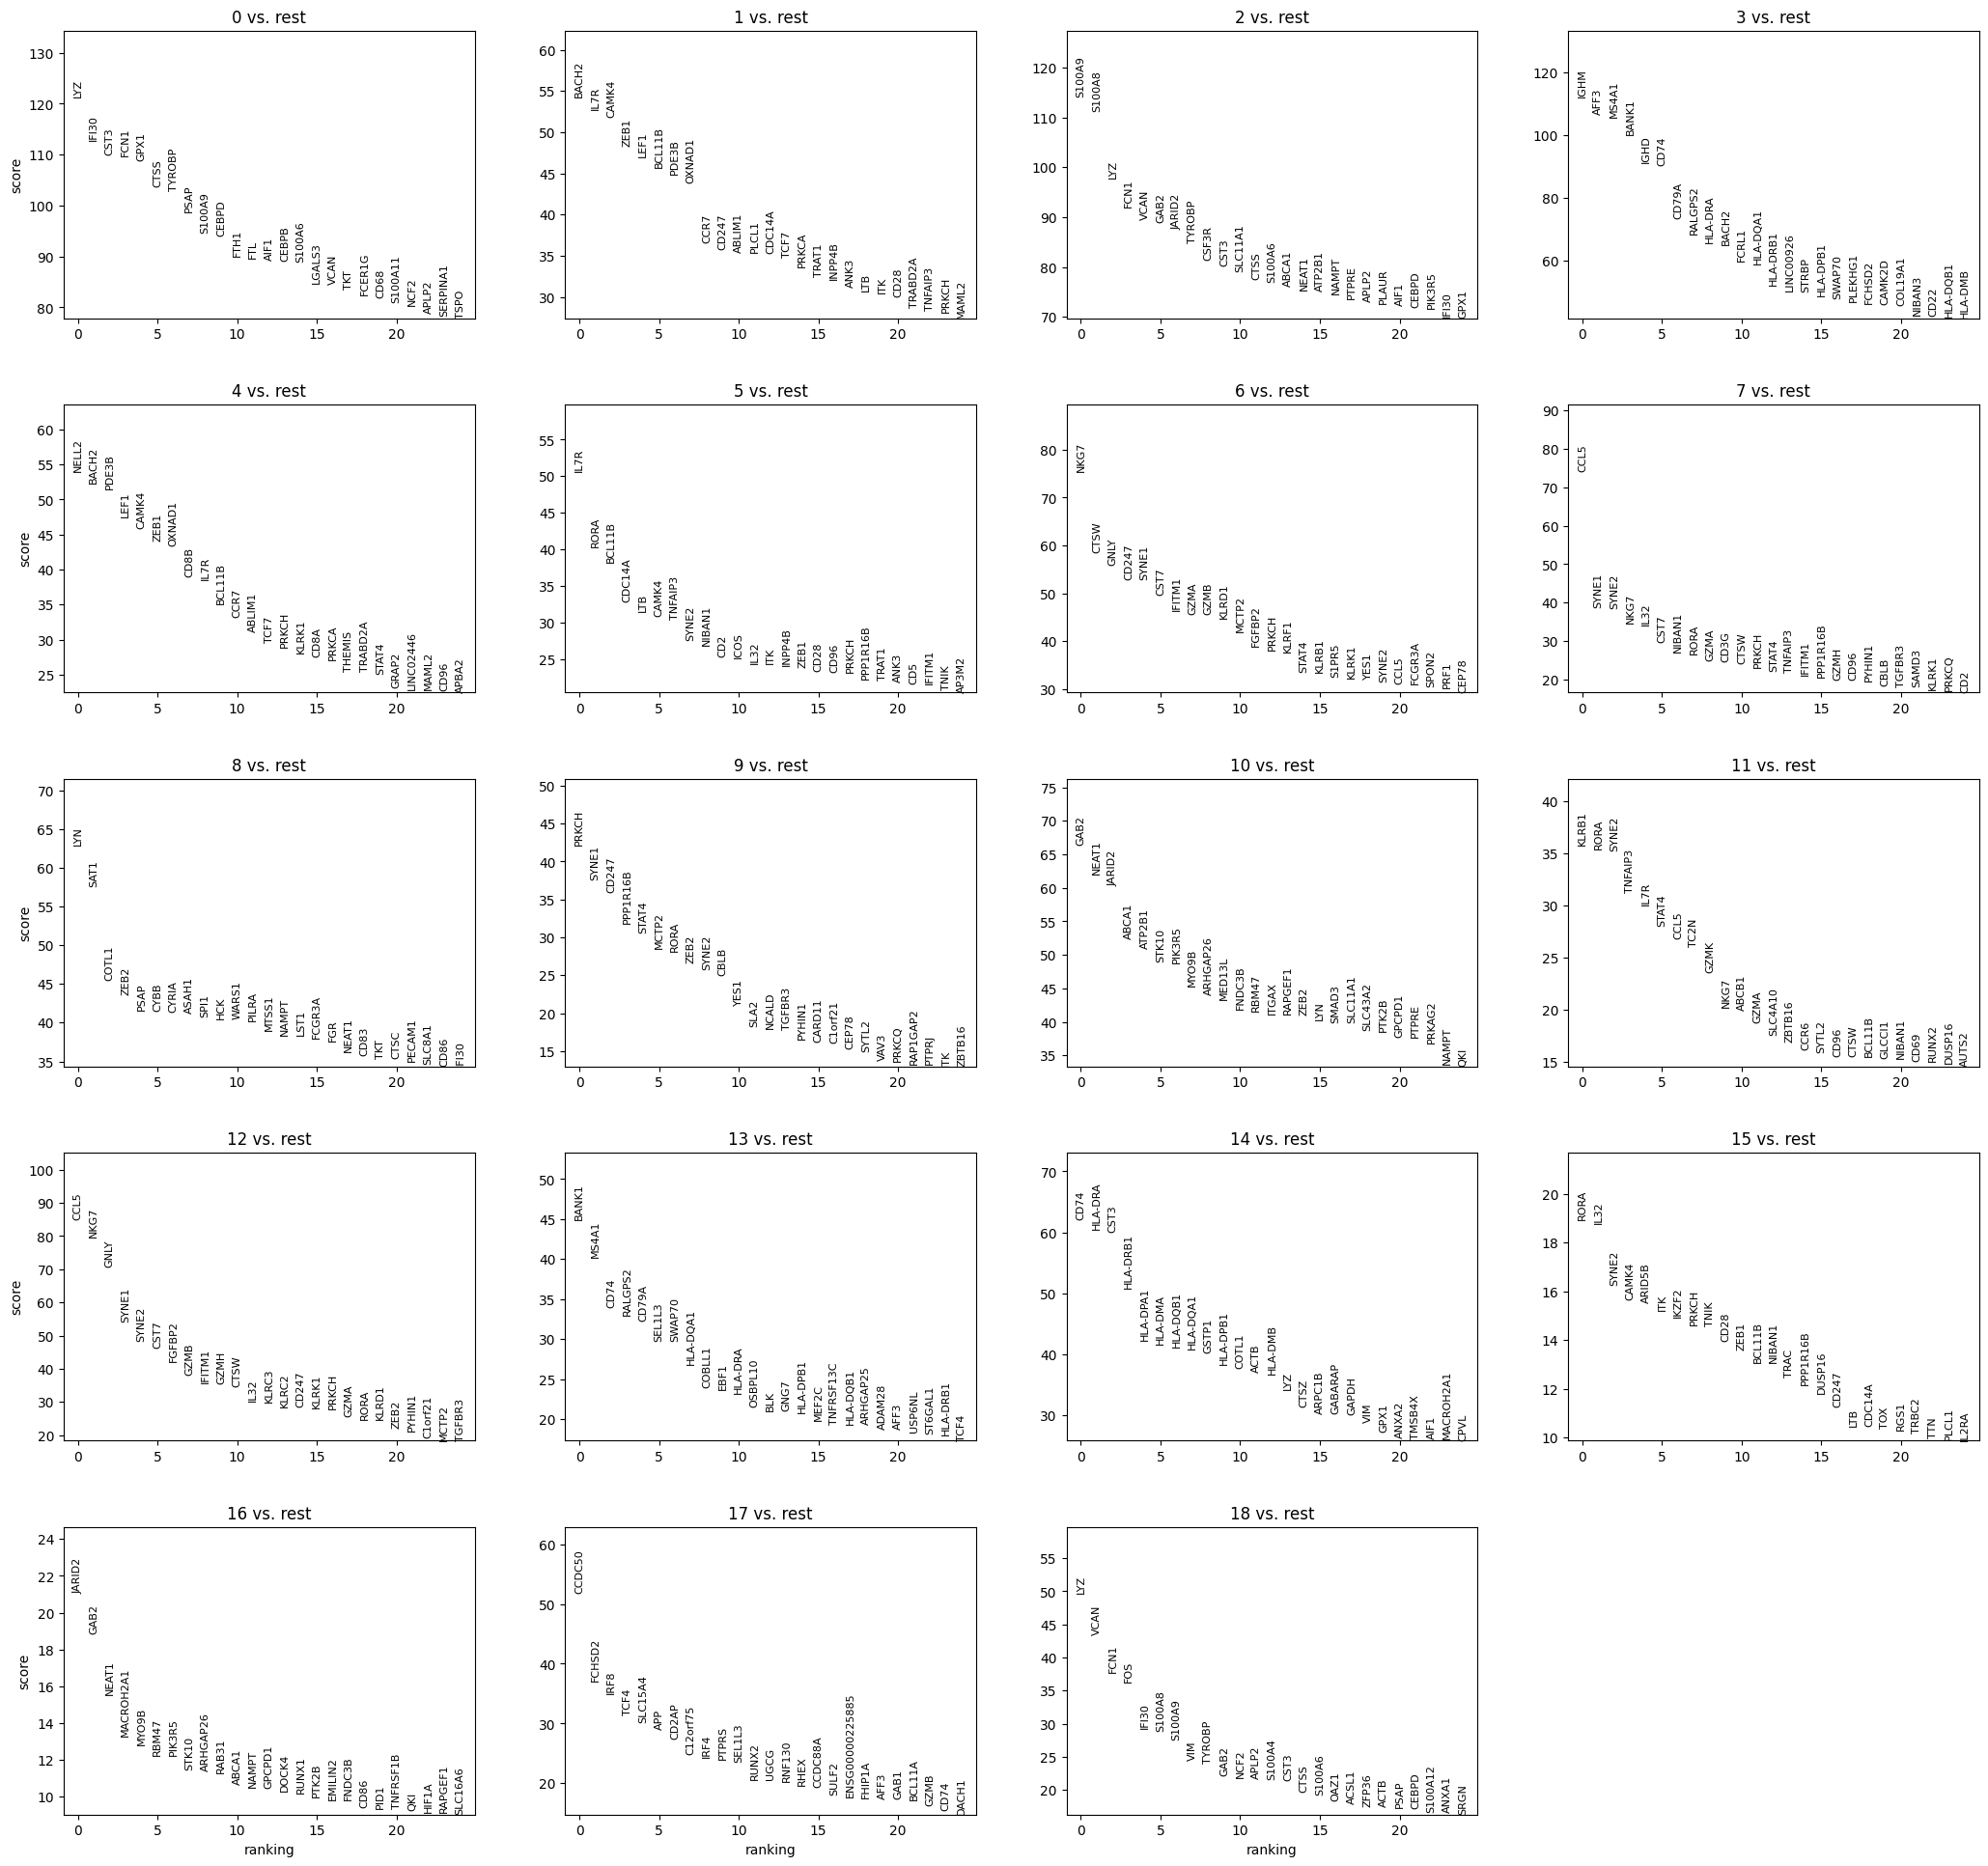

In [ ]:
## Ranking genes
sc.tl.rank_genes_groups(adata, "leiden", mask_var="highly_variable", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [ ]:
## Save the results
results_file = "/content/drive/MyDrive/Data Structures Project 1/results.h5ad"
adata.write(results_file)

To understand which genes would be useful to input into the UMAP, the sample had to be understood. PBMCs are composed of various immune cells. Each cluster contained high expressions of genes that are correlated to specific immune cells. I took highly expressed genes that could be used to represent one of four immune cell types:


* T cells
* NK/cytotoxic cells
* B cells
* Monocytes

Four genes were found (IL7R, NKG7, MS4A1, and S100A9).



In [ ]:
## Ensuring global connectivity
sc.tl.paga(adata)
sc.pl.paga(adata, plot=False)
sc.tl.umap(adata, init_pos='paga')
## Make UMAP
sc.tl.umap(adata)

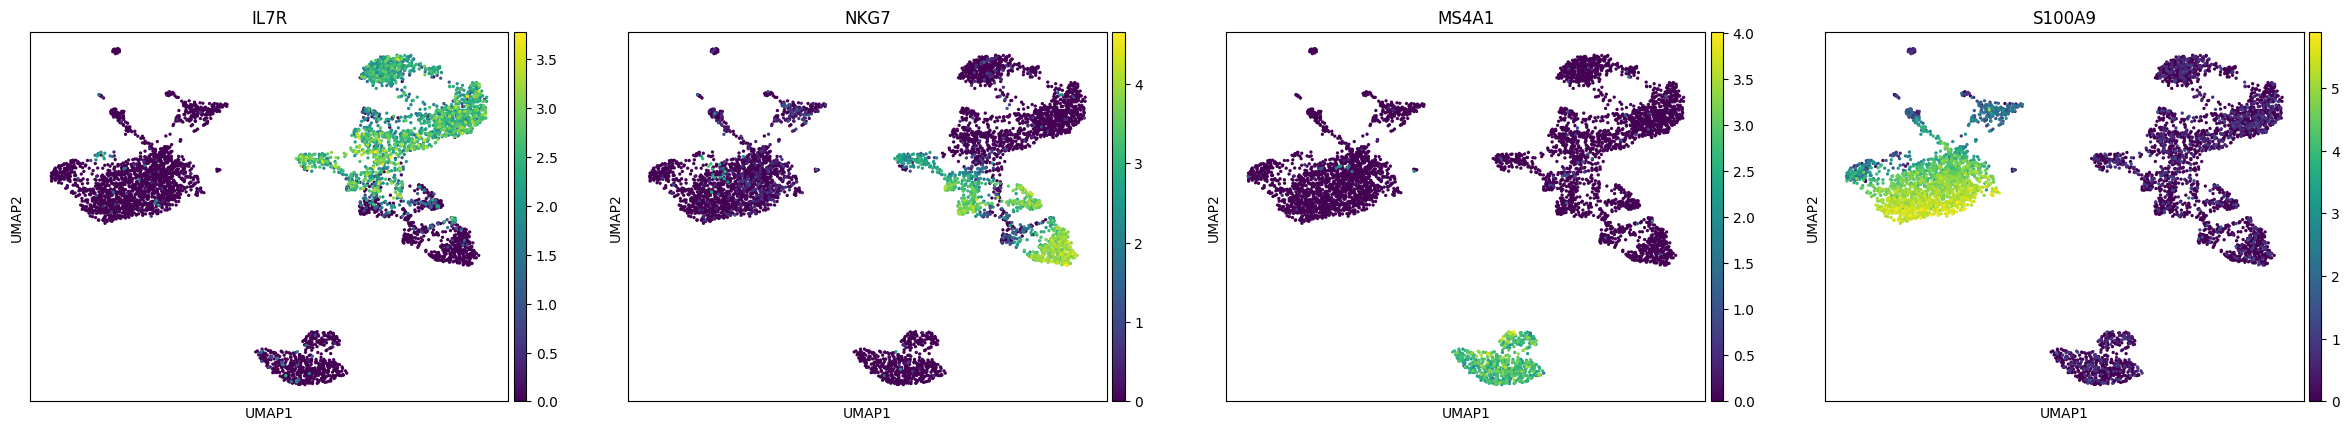

In [ ]:
## Plot UMAP based on distinct high gene expressions
sc.pl.umap(adata, color=[
    "IL7R",    # T cells
    "NKG7",    # NK/cytotoxic
    "MS4A1",   # B cells
    "S100A9"   # monocytes
])

# Clustering

Leiden clustering is recommended for scanpy, so it will be used to cluster the UMAP.

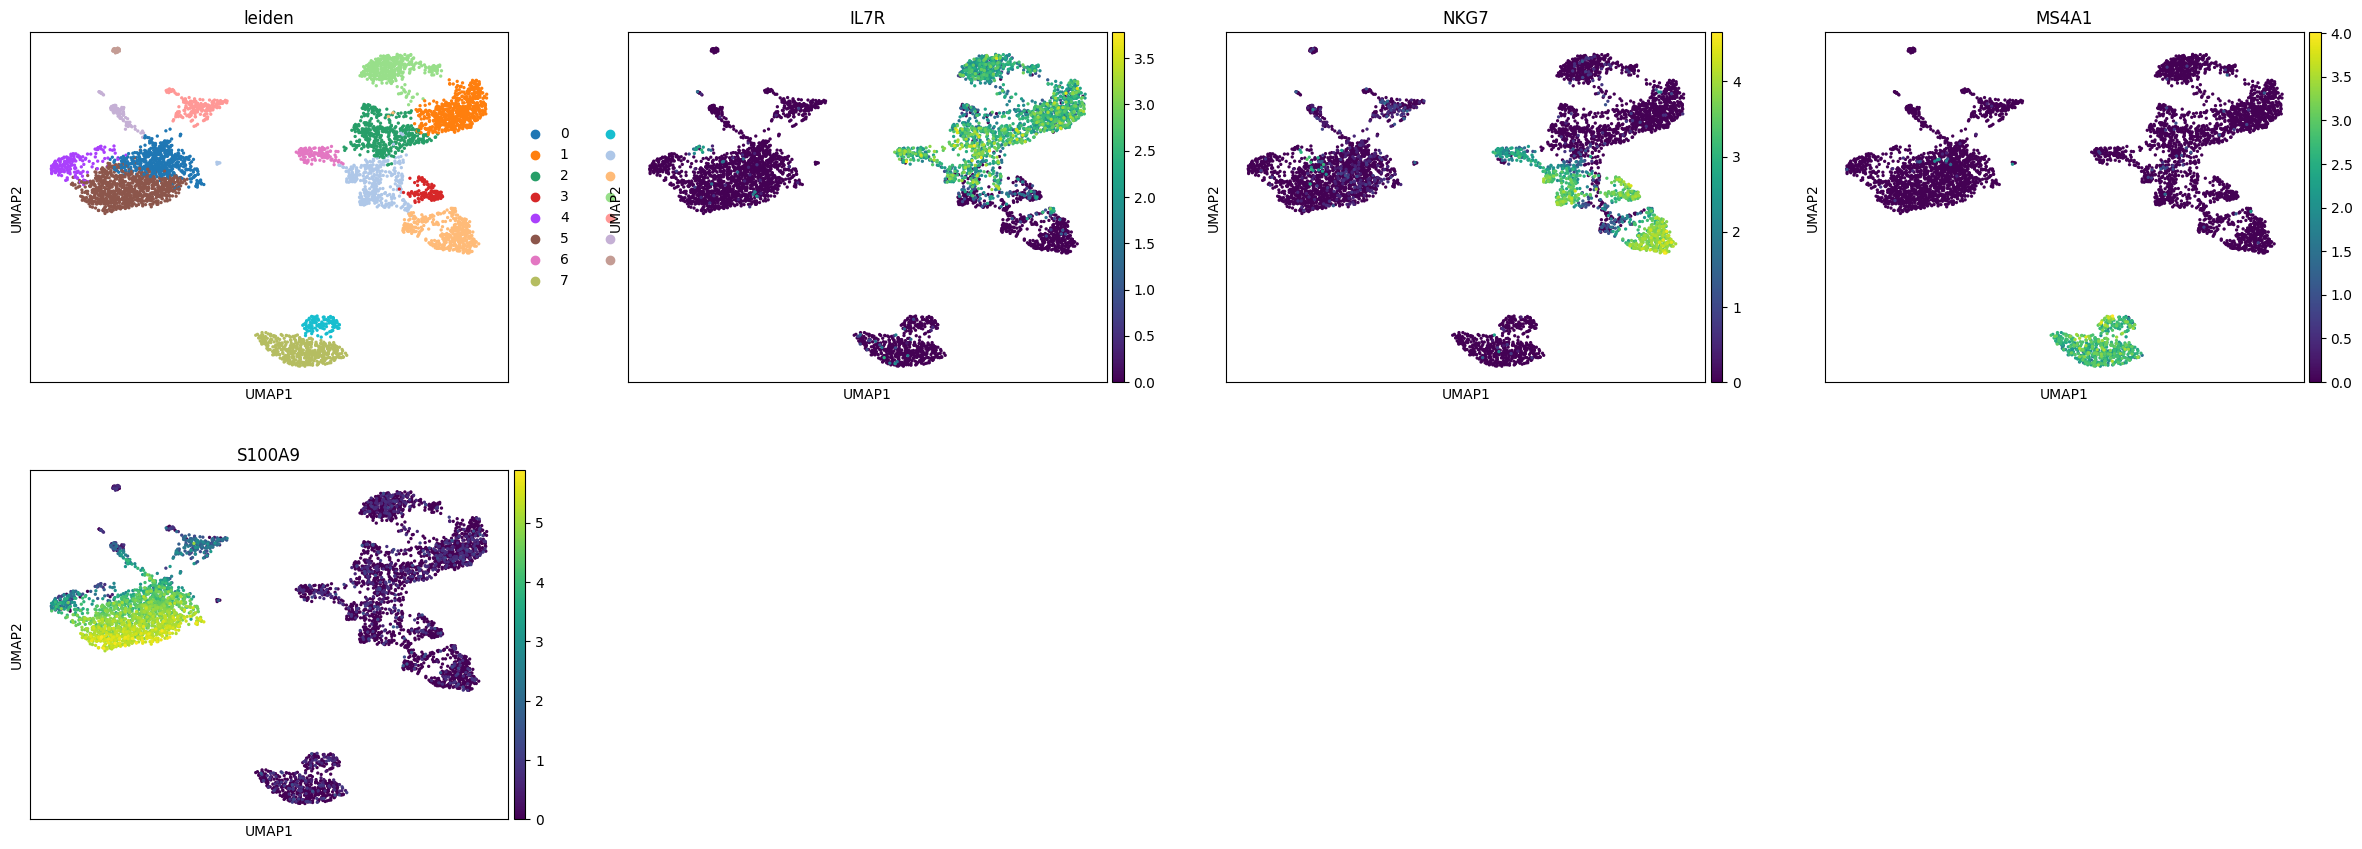

In [ ]:
## Running leiden clustering
sc.tl.leiden(
    adata,
    resolution=0.7,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
adata.obs["leiden"] = adata.obs["leiden"].copy()
adata.uns["leiden"] = adata.uns["leiden"].copy()
adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

## Plotting the clusters
sc.pl.umap(adata, color=["leiden", "IL7R", "NKG7", "MS4A1", "S100A9"])

# Marker Gene Identification & Annotation

Based on the genes that were ranked in the 'Normalization and Feaature Selection' section, it is put into a table showing the top 5 ranked genes per cluster below:

In [ ]:
## Show top 5 ranked gene per cluster
pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,LYZ,BACH2,S100A9,IGHM,NELL2,IL7R,NKG7,CCL5,LYN,PRKCH,GAB2,KLRB1,CCL5,BANK1,CD74,RORA,JARID2,CCDC50,LYZ
1,IFI30,IL7R,S100A8,AFF3,BACH2,RORA,CTSW,SYNE1,SAT1,SYNE1,NEAT1,RORA,NKG7,MS4A1,HLA-DRA,IL32,GAB2,FCHSD2,VCAN
2,CST3,CAMK4,LYZ,MS4A1,PDE3B,BCL11B,GNLY,SYNE2,COTL1,CD247,JARID2,SYNE2,GNLY,CD74,CST3,SYNE2,NEAT1,IRF8,FCN1
3,FCN1,ZEB1,FCN1,BANK1,LEF1,CDC14A,CD247,NKG7,ZEB2,PPP1R16B,ABCA1,TNFAIP3,SYNE1,RALGPS2,HLA-DRB1,CAMK4,MACROH2A1,TCF4,FOS
4,GPX1,LEF1,VCAN,IGHD,CAMK4,LTB,SYNE1,IL32,PSAP,STAT4,ATP2B1,IL7R,SYNE2,CD79A,HLA-DPA1,ARID5B,MYO9B,SLC15A4,IFI30


The gene markers were found using the PanglaoDB wesbite: https://panglaodb.se/


In [ ]:
marker_genes = [
    *["IL7R", "RORA", "CD247", "CCL5", "IL32"],    #T cells
    *["NKG7", "GNLY"],                       #NK cells
    *["MS4A1", "BANK1", "CD79A", "IGHM", "IGHD"],  #B cells
    *["S100A9", "S100A8", "VCAN"],             #Myeloid cells
    *["LYZ", "FCN1", "IFI30"],                 #Monocytes
]

The scores of the top five genes in each cluster is added so that we can see the significance of each gene.

In [ ]:
## Table of the scores of the top five genes per cluster
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
pd.DataFrame({f"{group}_{key[:1]}": result[key][group] for group in groups for key in ["names", "pvals"]}).head(5)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,...,14_n,14_p,15_n,15_p,16_n,16_p,17_n,17_p,18_n,18_p
0,LYZ,0.0,BACH2,0.000000e+00,S100A9,0.0,IGHM,0.000000e+00,NELL2,1.024219e-211,...,CD74,2.473069e-110,RORA,6.845942e-32,JARID2,1.797790e-23,CCDC50,3.058626e-30,LYZ,2.609732e-26
1,IFI30,0.0,IL7R,4.680531e-318,S100A8,0.0,AFF3,0.000000e+00,BACH2,3.604910e-296,...,HLA-DRA,1.527130e-94,IL32,7.765121e-31,GAB2,2.407629e-21,FCHSD2,5.686315e-26,VCAN,2.941487e-22
2,CST3,0.0,CAMK4,3.683900e-288,LYZ,0.0,MS4A1,0.000000e+00,PDE3B,5.086556e-253,...,CST3,1.158561e-97,SYNE2,2.592844e-27,NEAT1,2.951231e-18,IRF8,3.033012e-25,FCN1,3.993374e-21
3,FCN1,0.0,ZEB1,2.014413e-289,FCN1,0.0,BANK1,0.000000e+00,LEF1,9.881299e-193,...,HLA-DRB1,2.680259e-79,CAMK4,4.887264e-26,MACROH2A1,3.535184e-16,TCF4,1.079620e-23,FOS,1.280733e-18
4,GPX1,0.0,LEF1,9.878885e-237,VCAN,0.0,IGHD,1.061751e-316,CAMK4,6.799639e-206,...,HLA-DPA1,3.970898e-65,ARID5B,1.593009e-25,MYO9B,3.686308e-15,SLC15A4,2.533833e-23,IFI30,2.096087e-19


The annotated cell types will be superimposed on the 2D umap created before.

In [ ]:
## Create a library for the annotations
cluster_map = {
    "0": "Monocytes",
    "1": "Naive T",
    "2": "Monocytes",
    "3": "Monocytes/B",
    "4": "B cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "Cytotoxic T",
    "8": "Myeloid",
    "9": "Unclear",
    "10": "Unclear",
    "11": "T cells",
    "12": "NK/Cytotoxic",
    "13": "B cells",
    "14": "APC",
}

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_map)

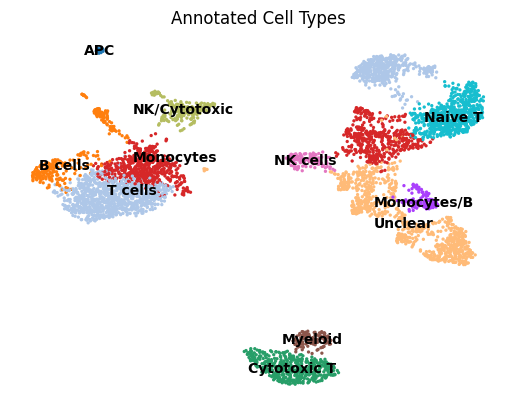

In [ ]:
## Map the annotated cell types
adata.obs["cell_type"] = adata.obs["leiden"].map({
    "0": "Monocytes",
    "1": "Naive T",
    "2": "Monocytes",
    "3": "Monocytes/B",
    "4": "B cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "Cytotoxic T",
    "8": "Myeloid",
    "9": "Unclear",
    "10": "Unclear",
    "11": "T cells",
    "12": "NK/Cytotoxic",
    "13": "B cells",
    "14": "APC",
})

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_map)
sc.pl.umap(adata, color="cell_type", legend_loc="on data", title="Annotated Cell Types", frameon=False)

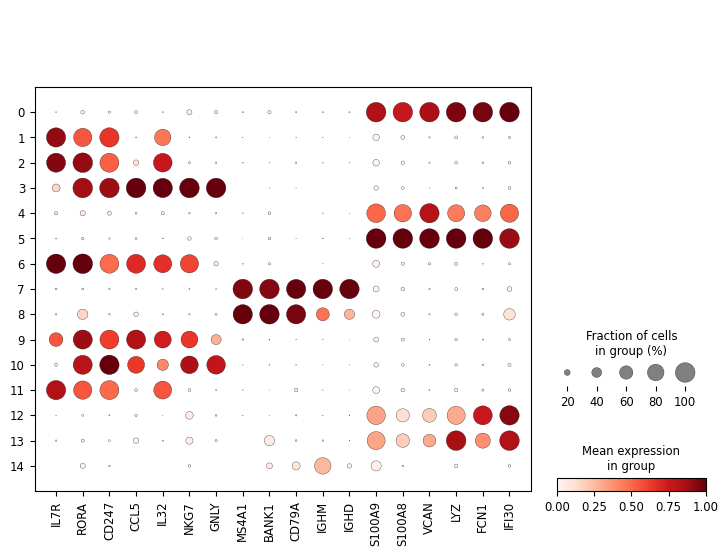

In [ ]:
## Marker gene dot plot
sc.pl.dotplot(adata, marker_genes, groupby="leiden", standard_scale="var")

The AnnData accumlated the following annotations:

In [ ]:
adata

AnnData object with n_obs × n_vars = 5266 × 24224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'rank_genes_groups', 'paga', 'leiden_sizes', 'umap', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [ ]:
## Save data; `compression='gzip'` saves disk space, and slightly slows down writing and subsequent reading
adata.write(results_file, compression="gzip")

# Biological Interpretation

My biological cell types match the expected cell types. PBMCs are lymphocytes which are composed of immune cells such as T, B, NK cells and monocytes. The annotated cell types present on the UMAP agree with the usual types of immune cells seen within PBMC samples.

The UMAP shows clear clustering with the left side showing myeloids (monocytes and APCs) and the right side showing lymphoids (B, T, and NK cells). We also see subtypes within these groups having separate clustering too with NK cells being separated from cytotoxic T cells.

The unclear cluster could be from genes that were not properly processed or filtered.

Overall, the UMAP is consistent with normal biological cell populations and functions.